# Challenge 1: Geodemographic Classification

In this challenge, you will replicate the process of creating a geodemographic classification using the k-means clustering algorithm. Please select any city in the UK except London, Liverpool, or Glasgow. The main goal is to generate a meaningful and informative classification that captures the diversity of areas in your dataset using the census data ( For England, you can try to use the 2021 or 2011 census, and for Scotland, you need to use the 2011 census data) 

1. Define the main goal for the geodemographic classification (marketing, retail and service planning). 
2. Look for census data from the selected city for which you would like to generate the geodemographic classification.
3. The census data at the Output Area OA level. Select multiple topics of at least four topics (socio-demographics, economics, health, and so on). Describe your topic selection accordingly based on the goal of your geodemographic classification. For example, if your geodemographics are related to marketing, Economic variables might be the appropriate selection. 
4. Identify the variables that will be crucial for effectively segmenting neighbourhoods. Evaluate how this choice may impact the classification results, including a DEA analysis.
5. Prepare, adjust or clean the dataset addressing any missing values or outliers that could distort the clustering results.
6. Include standardisation between areas and variables. Make an appropriate analysis and adjust the variable selection accordingly for any multicollinearity.
7. Utilize the k-means clustering algorithm to create a classification based on the selected variables.
8. Define the optimum number of clusters (i.e., using the Elblow method). Experiment with different values of k.
9. Evaluate your cluster groups (e.g., using PCA) and interpret your cluster centres. Describe your results and repeat the process to adjust the variable selection and cluster groups to provide more meaningful results for your geodemographic goal. Interpret the characteristics of each cluster. What demographic patterns or similarities are prevalent within each group?
10. Map the final cluster groups
11. Finish the analysis by naming the final clusters and plotting a final map that includes the census values and the provided names.
12. Finally, acknowledge the subjective nature of classification and make analytical decisions to produce an optimum classification for your specific purpose. Reflect on the challenges and insights gained during the classification process. Ensure you document your analytical decisions and the rationale behind any important decision. Once your geodemographics are constructed, describe the potential use cases for the geodemographic classification you have built based on your initial goal.

In [ ]:
#defining the main goal for the geodemographic classification

I will be examining data for the city of Brigthton and Hove from a marketing perspective using data from the 2021 Census for England and Wales.

**Study area**: Brighton and Hove
**Geography (spatial units)** 2021 Lower Tier Local Authorities
**Dataset**: 2021 United Kingdom Census 

**Census Variables Used** - 
- Age structure
- Economic activity
- Ethnicity
- General Health
- Highest Level of Educational Qualification
- Industry
- Living Arrangement
- Marital and civil partnership status
- Religion
- Sex

Reference: ONS (2021). Census - Office for National Statistics. [online] Ons.gov.uk. Available at: https://www.ons.gov.uk/census.

In [ ]:
#identifying variables to help with a marketing analysis 

In [ ]:
#preparing the variables for analysis

In [1]:
#reading in selected raw census data (csv files)
import pandas as pd
import os

csv_directory = "data/lab_raw_data"

csv_files = [file for file in os.listdir(csv_directory) if file.endswith(".csv")]

# an empty DataFrame to store the merged data
merged_data = pd.DataFrame()

In [2]:
#merging the csv files
for csv_file in csv_files:
    csv_path = os.path.join(csv_directory, csv_file)
    df_csv = pd.read_csv(csv_path, low_memory=False)
    merged_data = pd.concat([merged_data, df_csv], axis=1)

merged_data.to_csv("data/lab_raw_data/merged_lab_data.csv", index=False)

In [16]:
#checking out first few columns of merged variables
merged_data.head()

,Lower tier local authorities Code,Lower tier local authorities,Age (6 categories) Code,Age (6 categories),Observation,Lower tier local authorities Code,Lower tier local authorities,Religion (10 categories) Code,Religion (10 categories),Observation,...,Lower tier local authorities Code,Lower tier local authorities,Religion (10 categories) Code,Religion (10 categories),Observation,Lower tier local authorities Code,Lower tier local authorities,Religion (10 categories) Code,Religion (10 categories),Observation
0,E06000043,Brighton and Hove,1.0,Aged 15 years and under,41736.0,E06000043,Brighton and Hove,-8,Does not apply,0,...,E06000043,Brighton and Hove,-8,Does not apply,0,E06000043,Brighton and Hove,-8,Does not apply,0
1,E06000043,Brighton and Hove,2.0,Aged 16 to 24 years,42928.0,E06000043,Brighton and Hove,1,No religion,152966,...,E06000043,Brighton and Hove,1,No religion,152966,E06000043,Brighton and Hove,1,No religion,152966
2,E06000043,Brighton and Hove,3.0,Aged 25 to 34 years,41470.0,E06000043,Brighton and Hove,2,Christian,85629,...,E06000043,Brighton and Hove,2,Christian,85629,E06000043,Brighton and Hove,2,Christian,85629
3,E06000043,Brighton and Hove,4.0,Aged 35 to 49 years,59086.0,E06000043,Brighton and Hove,3,Buddhist,2455,...,E06000043,Brighton and Hove,3,Buddhist,2455,E06000043,Brighton and Hove,3,Buddhist,2455
4,E06000043,Brighton and Hove,5.0,Aged 50 to 64 years,52908.0,E06000043,Brighton and Hove,4,Hindu,2100,...,E06000043,Brighton and Hove,4,Hindu,2100,E06000043,Brighton and Hove,4,Hindu,2100


In [6]:
#working with only the lower tier local authority of Brighton and Hove
import pandas as pd
import geopandas as gpd

#first have to import the shapefile of local authority boundaries for England
shp_path = "data/lab_raw_data/LPA_APR_2022_UK_BFC.shp"
gdf = gpd.read_file(shp_path)

gdf.head()

,LPA22CD,LPA22NM,BNG_E,BNG_N,LONG,LAT,geometry
0,E60000001,County Durham LPA,410381,532242,-1.84050,54.685131,"POLYGON ((428366.003 554230.403, 428358.203 55..."
1,E60000002,Darlington LPA,428029,515648,-1.56835,54.535339,"POLYGON ((436388.002 522354.197, 436392.298 52..."
2,E60000003,Hartlepool LPA,447160,531474,-1.27018,54.676140,"MULTIPOLYGON (((450154.599 525938.201, 450140...."
3,E60000004,Middlesbrough LPA,451141,516887,-1.21099,54.544670,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ..."
4,E60000005,Northumberland LPA,397860,571351,-2.03502,55.036671,"MULTIPOLYGON (((429380.896 604848.303, 429384...."


In [8]:
#filtering the local authority boundaries to only include Brighton and Hove
brighton_gdf = gdf[gdf["LPA22CD"] == "E60000222"]
print(brighton_gdf)

       LPA22CD                LPA22NM   BNG_E   BNG_N     LONG       LAT  \
214  E60000222  Brighton and Hove LPA  529831  106336 -0.15734  50.84198   

                                              geometry  
214  MULTIPOLYGON (((536074.947 104311.5, 536087.65...  


In [9]:
#saving the local authority boundary of Brighton and Hove
brighton_gdf.to_file("brighton_hove_boundaries.shp", driver="ESRI Shapefile")

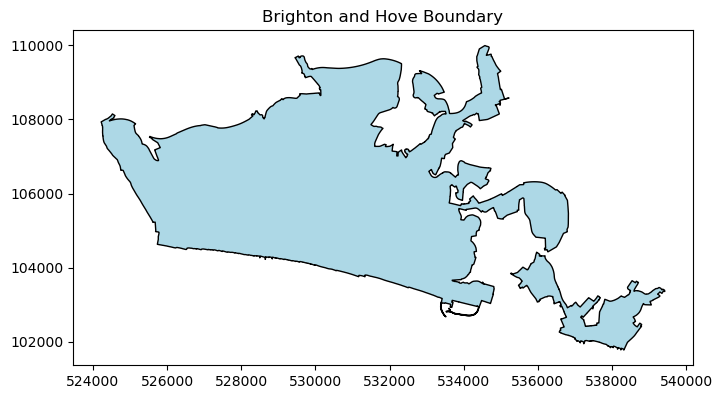

In [11]:
#visualising the boundary of our selected city of Study
import matplotlib.pyplot as plt
brighton_gdf.plot(figsize=(8,6), edgecolor="black", color="lightblue")
plt.title("Brighton and Hove Boundary")
plt.show()

In [15]:
#merging the GeoDataFrame of our spatial area with the DataFrame of variables

#loading our dataframe for variables for Brighton and Hove
csv_path = "data/lab_raw_data/merged_lab_data.csv"
csv_data = pd.read_csv(csv_path, low_memory=False)

#merging the gdf and df
merged_data = brighton_gdf.merge(csv_data, left_on='code', right_on='LPA22CD', how='left')

#displaying the first few rows to verify a successful merge
print(merged_brighton_data.head())

#saving the merged data as a new shapefile
merged_brighton_data.to_file("data/lab_raw_data/merged_brighton_data.shp", driver="ESRI Shapefile")

KeyError: 'LPA22CD'

In [ ]:
#Descriptive Statistics Analysis - DEA of variables